In [23]:
import kagglehub
import pandas as pd
import numpy as np
import os


try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv' ))
    print('Thursday data confirmed. :)')

except Exception as e:
    print(f'Something went wrong {e}')


data.head()

Thursday data confirmed. :)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [24]:
from sklearn.preprocessing import LabelEncoder

data.columns = data.columns.str.strip()

le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1',
    'Avg Fwd Segment Size',
    'Subflow fwd bytes',
    'Subflow fwd packets',
    'Subflow bwd Packets',
    'Subflow bwd bytes',
    'Packet Length Variance' 
]

data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data = data.drop(columns=columns_drop, errors='ignore')

X = data.drop('Label', axis=1)
y = data['Label']

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split FIRST before the scaler ever sees the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Fit scaler ONLY on training data, then apply to test separately
# This prevents test set statistics from leaking into training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train_scaled)
X_test_t  = torch.FloatTensor(X_test_scaled)
y_train_t = torch.LongTensor(y_train.values)
y_test_t  = torch.LongTensor(y_test.values)

class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.layers(x)

input_size = X_train_t.shape[1]
num_classes = len(y.unique())
model = NeuralNet(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=512, shuffle=True)

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model.to(device)

for epoch in range(10):
    model.train()
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}/10 Loss: {loss.item():.4f}')

    model.eval()
    with torch.no_grad():
        X_test_device = X_test_t.to(device)
        y_pred = model(X_test_device).argmax(dim=1).cpu().numpy()

    print(classification_report(y_test, y_pred))

Epoch 1/10 Loss: 0.0210


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99     33632
           1       0.00      0.00      0.00       273
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00       137

    accuracy                           0.99     34047
   macro avg       0.25      0.25      0.25     34047
weighted avg       0.98      0.99      0.98     34047

Epoch 2/10 Loss: 0.0149
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33632
           1       0.49      0.81      0.61       273
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00       137

    accuracy                           0.99     34047
   macro avg       0.37      0.45      0.40     34047
weighted avg       0.99      0.99      0.99     34047



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 3/10 Loss: 0.0201
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33632
           1       0.53      0.92      0.67       273
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00       137

    accuracy                           0.99     34047
   macro avg       0.38      0.48      0.42     34047
weighted avg       0.99      0.99      0.99     34047



...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 9/10 Loss: 0.0138
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33632
           1       0.55      0.97      0.70       273
           2       0.00      0.00      0.00         5
           3       1.00      0.04      0.07       137

    accuracy                           0.99     34047
   macro avg       0.64      0.50      0.44     34047
weighted avg       1.00      0.99      0.99     34047



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 10/10 Loss: 0.0127
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     33632
           1       0.69      0.51      0.59       273
           2       0.00      0.00      0.00         5
           3       1.00      0.04      0.07       137

    accuracy                           0.99     34047
   macro avg       0.67      0.39      0.41     34047
weighted avg       0.99      0.99      0.99     34047



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


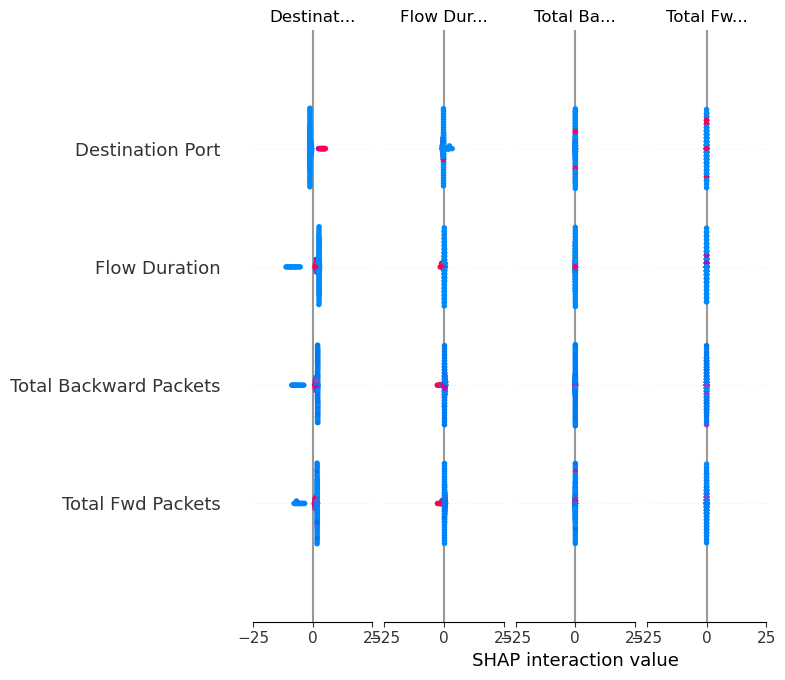

In [26]:
import matplotlib.pyplot as plt
import shap

model.to('cpu')
X_train_cpu = X_train_t[:100].to("cpu")
X_test_cpu  = X_test_t[:100].to('cpu')
explainer = shap.DeepExplainer(model, X_train_cpu)
shap_values = explainer.shap_values(X_test_cpu)
shap.summary_plot(shap_values, X_test_scaled[:100], feature_names=X.columns, class_names=le.classes_, show=False)
plt.tight_layout()
plt.show()